# **LDA Topic Modeling**


In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Text preprocessing
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Sklearn for LDA and vectorization
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Install gensim if not already installed
!pip install gensim

# Gensim (alternative LDA implementation)
import gensim
from gensim import corpora
from gensim.models import LdaModel

# Download required NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Set style for visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("All libraries imported successfully!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


All libraries imported successfully!


[nltk_data]   Package omw-1.4 is already up-to-date!


In [2]:
# Load the dataset
df = pd.read_csv('/content/sample_data/yelp_reviews_55403.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\n" + "="*50)
print("Column Names and Types:")
print(df.dtypes)
print("\n" + "="*50)
print("First few rows:")
df.head()

Dataset Shape: (100, 16)

Column Names and Types:
business_name                 object
business_id                   object
address                       object
phone                        float64
business_rating              float64
business_review_count          int64
price_range                   object
categories                    object
review_id                    float64
review_rating                float64
review_text                   object
review_time_created          float64
user_name                    float64
user_id                      float64
review_text_source            object
synthetic_sentiment_label     object
dtype: object

First few rows:


,business_name,business_id,address,phone,business_rating,business_review_count,price_range,categories,review_id,review_rating,review_text,review_time_created,user_name,user_id,review_text_source,synthetic_sentiment_label
0,Gai Noi,aC5rqV0NR8DSPGsz_G4phg,"1610 Harmon Pl, Minneapolis, MN 55403",NaN,4.3,590,$$,"Desserts, Noodles, Laotian",NaN,NaN,I had a very good visit at Gai Noi. The desser...,NaN,NaN,NaN,synthetic,positive
1,The Butcher's Tale,XRXkdaUqf_SQ4tRlnJ_sHw,"1121 Hennepin Ave, Minneapolis, MN 55403",1.612236e+10,4.6,198,NaN,"American, Cocktail Bars",NaN,NaN,I had a excellent visit at The Butcher's Tale....,NaN,NaN,NaN,synthetic,positive
2,Red Rabbit Minneapolis,Z9UFvaj_zeaVSg4Ta8D9qQ,"201 N Washington Ave, Minneapolis, MN 55401",1.612768e+10,4.4,1064,$$,"Italian, Pizza, Bars",NaN,NaN,I left Red Rabbit Minneapolis feeling underwhe...,NaN,NaN,NaN,synthetic,negative
3,Owamni,SohhXXtdcPjpM1YPf9MG-A,"420 1st St S, Minneapolis, MN 55401",1.612444e+10,4.4,611,$$$,"New American, Gluten-Free",NaN,NaN,Owamni stands out for dependable quality. Port...,NaN,NaN,NaN,synthetic,positive
4,Spoon and Stable,5olLs-K-_k_rWrrNLjvy0w,"211 N 1st St, Minneapolis, MN 55401",1.612225e+10,4.4,1434,$$$,"New American, Bars",NaN,NaN,I left Spoon and Stable feeling underwhelmed. ...,NaN,NaN,NaN,synthetic,negative


In [3]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print("\n" + "="*50)

# Basic statistics
print("Dataset Info:")
print(df.info())

Missing Values:
business_name                  0
business_id                    0
address                        0
phone                          5
business_rating                0
business_review_count          0
price_range                   22
categories                     0
review_id                    100
review_rating                100
review_text                    0
review_time_created          100
user_name                    100
user_id                      100
review_text_source             0
synthetic_sentiment_label      0
dtype: int64

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   business_name              100 non-null    object 
 1   business_id                100 non-null    object 
 2   address                    100 non-null    object 
 3   phone                      95 non-null 

In [4]:
# Display sample reviews
print("Sample Reviews:")
print("="*50)
for idx, review in enumerate(df['review_text'].head(3), 1):
    print(f"\nReview {idx}:")
    print(review[:300] + "..." if len(review) > 300 else review)
    print("-"*50)

Sample Reviews:

Review 1:
I had a very good visit at Gai Noi. The desserts dishes were flavorful and well-presented. A good option for this area when you want reliable food.
--------------------------------------------------

Review 2:
I had a excellent visit at The Butcher's Tale. Portions were fair and the overall value felt reasonably priced. Worth trying if you are exploring restaurants in 55403.
--------------------------------------------------

Review 3:
I left Red Rabbit Minneapolis feeling underwhelmed. For a moderately priced place, the value did not feel justified. I would not rush back based on this experience.
--------------------------------------------------


# Text Processing

In [5]:
# Initialize preprocessing tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Add custom stop words specific to Yelp reviews
custom_stop_words = {'restaurant', 'place', 'food', 'yelp', 'order', 'ordered', 'get', 'got', 'go', 'went'}
stop_words.update(custom_stop_words)

# Download the missing 'punkt_tab' resource
nltk.download('punkt_tab')

def preprocess_text(text):
    """
    Preprocess the review text:
    - Convert to lowercase
    - Remove special characters and digits
    - Tokenize
    - Remove stop words
    - Lemmatize
    """
    if pd.isna(text):
        return ""

    # Convert to lowercase
    text = text.lower()

    # Remove special characters and digits
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stop words and lemmatize
    tokens = [lemmatizer.lemmatize(token) for token in tokens
              if token not in stop_words and len(token) > 3]

    return ' '.join(tokens)

# Apply preprocessing
print("Preprocessing reviews...")
df['processed_text'] = df['review_text'].apply(preprocess_text)

# Remove empty reviews after preprocessing
df = df[df['processed_text'].str.strip() != '']

print(f"Preprocessing complete! {len(df)} reviews remaining after removing empty reviews.")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...


Preprocessing reviews...


[nltk_data]   Package punkt_tab is already up-to-date!


Preprocessing complete! 100 reviews remaining after removing empty reviews.


In [6]:
# Compare original and preprocessed text
print("Example of Preprocessing:")
print("="*50)
print("ORIGINAL:")
print(df['review_text'].iloc[0][:400])
print("\n" + "="*50)
print("PREPROCESSED:")
print(df['processed_text'].iloc[0][:400])

Example of Preprocessing:
ORIGINAL:
I had a very good visit at Gai Noi. The desserts dishes were flavorful and well-presented. A good option for this area when you want reliable food.

PREPROCESSED:
good visit dessert dish flavorful wellpresented good option area want reliable


# Create Document-Term Matrix

In [7]:
# Create Document-Term Matrix using CountVectorizer
# LDA works better with raw counts rather than TF-IDF

vectorizer = CountVectorizer(
    max_df=0.85,  # Ignore terms that appear in more than 85% of documents
    min_df=5,      # Ignore terms that appear in less than 5 documents
    max_features=1000,  # Limit to top 1000 features
    ngram_range=(1, 2)  # Include unigrams and bigrams
)

# Fit and transform the processed text
dtm = vectorizer.fit_transform(df['processed_text'])

# Get feature names
feature_names = vectorizer.get_feature_names_out()

print(f"Document-Term Matrix Shape: {dtm.shape}")
print(f"Number of documents: {dtm.shape[0]}")
print(f"Number of terms: {dtm.shape[1]}")
print(f"\nSample feature names: {feature_names[:20]}")

Document-Term Matrix Shape: (100, 205)
Number of documents: 100
Number of terms: 205

Sample feature names: ['actively' 'actively recommend' 'american' 'american dish' 'area'
 'area want' 'atmosphere' 'atmosphere felt' 'atmosphere noisy' 'attentive'
 'attentive atmosphere' 'back' 'back based' 'back recommend' 'balanced'
 'balanced deeply' 'based' 'based experience' 'best' 'best meal']


# LDA Model

In [8]:
# Build LDA Model using scikit-learn
n_topics = 5  # Number of topics to extract

lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    max_iter=20,
    learning_method='online',
    random_state=42,
    batch_size=128,
    evaluate_every=5,
    n_jobs=-1,
    verbose=1
)

print(f"Training LDA model with {n_topics} topics...")
lda_output = lda_model.fit_transform(dtm)
print("Model training complete!")

Training LDA model with 5 topics...
iteration: 1 of max_iter: 20
iteration: 2 of max_iter: 20
iteration: 3 of max_iter: 20
iteration: 4 of max_iter: 20
iteration: 5 of max_iter: 20, perplexity: 170.1278
iteration: 6 of max_iter: 20
iteration: 7 of max_iter: 20
iteration: 8 of max_iter: 20
iteration: 9 of max_iter: 20
iteration: 10 of max_iter: 20, perplexity: 144.6784
iteration: 11 of max_iter: 20
iteration: 12 of max_iter: 20
iteration: 13 of max_iter: 20
iteration: 14 of max_iter: 20
iteration: 15 of max_iter: 20, perplexity: 136.5765
iteration: 16 of max_iter: 20
iteration: 17 of max_iter: 20
iteration: 18 of max_iter: 20
iteration: 19 of max_iter: 20
iteration: 20 of max_iter: 20, perplexity: 132.9769
Model training complete!


In [9]:
# Check model perplexity and log-likelihood
print(f"Model Perplexity: {lda_model.perplexity(dtm):.2f}")
print(f"Log Likelihood: {lda_model.score(dtm):.2f}")

Model Perplexity: 132.98
Log Likelihood: -11315.87


# Analyze Topics

In [10]:
# Function to display top words for each topic
def display_topics(model, feature_names, n_top_words=10):
    """Display the top words for each topic"""
    topics = {}

    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[-n_top_words:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        topics[f"Topic {topic_idx + 1}"] = top_words

        print(f"\nTopic {topic_idx + 1}:")
        print(", ".join(top_words))

    return topics

# Display topics
print("="*70)
print("DISCOVERED TOPICS AND THEIR TOP WORDS")
print("="*70)
topics_dict = display_topics(lda_model, feature_names, n_top_words=15)

DISCOVERED TOPICS AND THEIR TOP WORDS

Topic 1:
good, felt, experience, good option, want reliable, area, area want, option area, reliable, option, want, stand dependable, dependable, quality, stand

Topic 2:
dish, felt, experience, expectation, would, felt inconsistent, dish lacked, inconsistent, flavor, flavor felt, lacked, lacked flavor, exceeded expectation, exceeded, rating still

Topic 3:
experience, based, rush, rush back, would rush, back based, based experience, back, would, expectation visit, meet expectation, meet, felt, option, stronger option

Topic 4:
visit, future visit, hope future, visit better, missed mark, better missed, missed, better, hope, future, mark, felt, experience, disappointing, service

Topic 5:
felt, value felt, value, worth, priced, moderately, moderately priced, excellent, fair, overall, portion fair, fair overall, overall value, portion, experience


In [11]:
# Create a more detailed topic analysis
topic_word_matrix = pd.DataFrame(
    lda_model.components_,
    columns=feature_names,
    index=[f'Topic_{i+1}' for i in range(n_topics)]
)

print("\nTop 10 words per topic with their weights:")
print("="*70)
for topic in topic_word_matrix.index:
    print(f"\n{topic}:")
    top_words = topic_word_matrix.loc[topic].nlargest(10)
    for word, weight in top_words.items():
        print(f"  {word}: {weight:.4f}")


Top 10 words per topic with their weights:

Topic_1:
  good: 28.4946
  felt: 16.7007
  experience: 16.2626
  good option: 16.0182
  want reliable: 16.0070
  area: 16.0006
  area want: 15.9850
  option area: 15.9832
  reliable: 15.9776
  option: 15.9513

Topic_2:
  dish: 15.1589
  felt: 11.7005
  experience: 10.0932
  expectation: 9.6148
  would: 8.8955
  felt inconsistent: 8.0146
  dish lacked: 8.0126
  inconsistent: 8.0092
  flavor: 8.0075
  flavor felt: 8.0005

Topic_3:
  experience: 17.6516
  based: 12.4374
  rush: 12.4320
  rush back: 12.4318
  would rush: 12.4254
  back based: 12.4101
  based experience: 12.4018
  back: 12.3382
  would: 11.4307
  expectation visit: 6.8936

Topic_4:
  visit: 8.6409
  future visit: 6.8096
  hope future: 6.8058
  visit better: 6.8024
  missed mark: 6.8007
  better missed: 6.7994
  missed: 6.7988
  better: 6.7943
  hope: 6.7889
  future: 6.7889

Topic_5:
  felt: 26.9223
  value felt: 20.5999
  value: 20.5913
  worth: 17.1945
  priced: 16.9467
  moder

# Visualize Topic Distribution

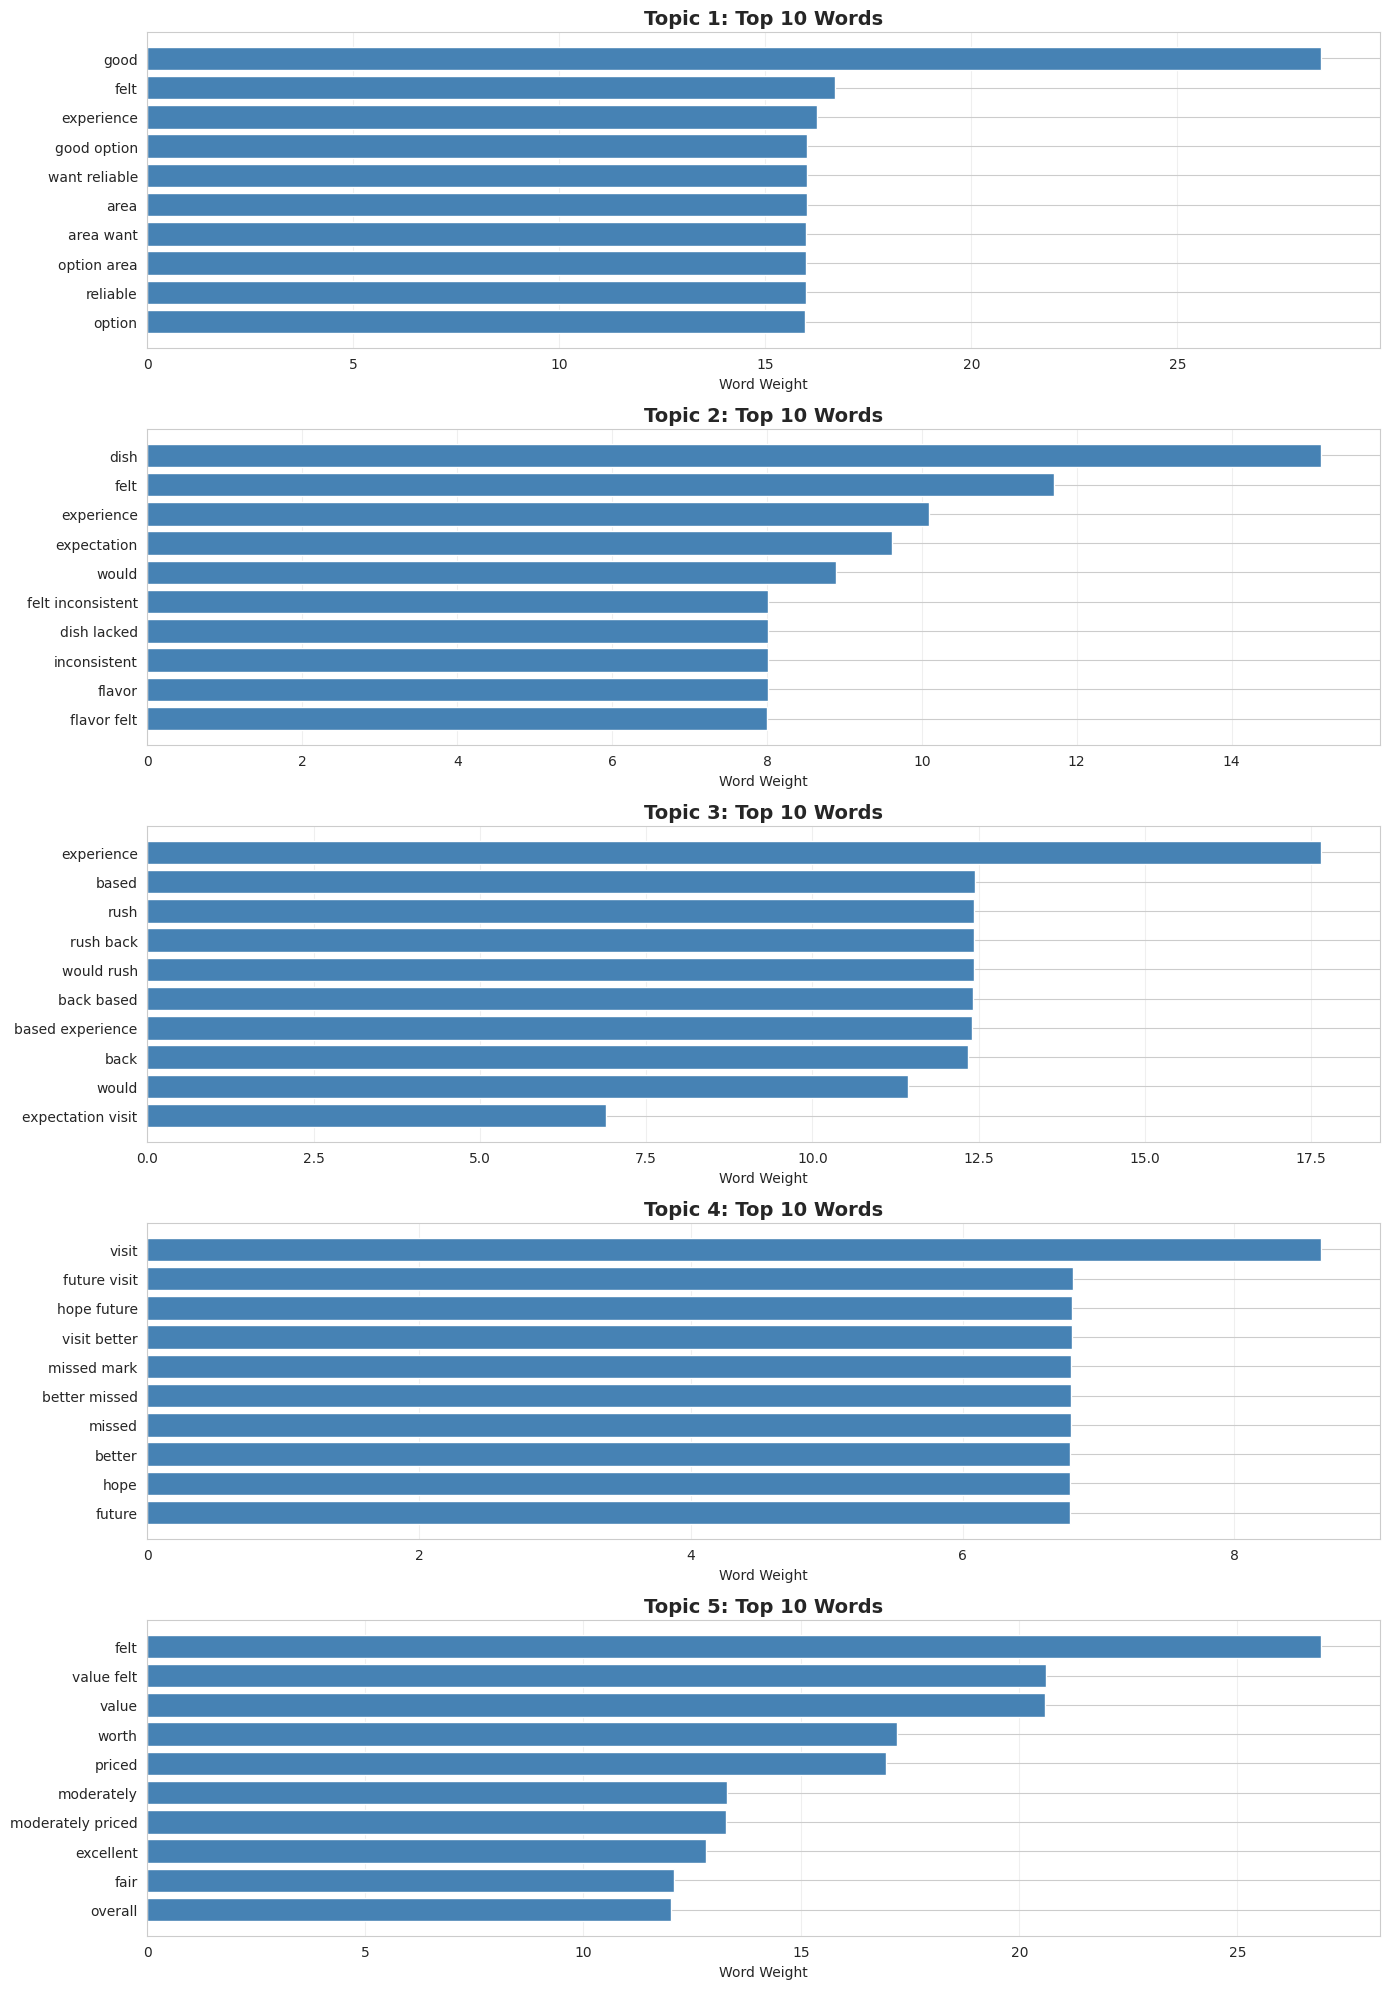

In [12]:
# Visualize top words for each topic
n_top_words = 10

fig, axes = plt.subplots(n_topics, 1, figsize=(14, 4*n_topics))
if n_topics == 1:
    axes = [axes]

for topic_idx, ax in enumerate(axes):
    top_indices = lda_model.components_[topic_idx].argsort()[-n_top_words:][::-1]
    top_words = [feature_names[i] for i in top_indices]
    top_weights = lda_model.components_[topic_idx][top_indices]

    ax.barh(range(n_top_words), top_weights, color='steelblue')
    ax.set_yticks(range(n_top_words))
    ax.set_yticklabels(top_words)
    ax.invert_yaxis()
    ax.set_xlabel('Word Weight')
    ax.set_title(f'Topic {topic_idx + 1}: Top {n_top_words} Words', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('lda_topics_bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

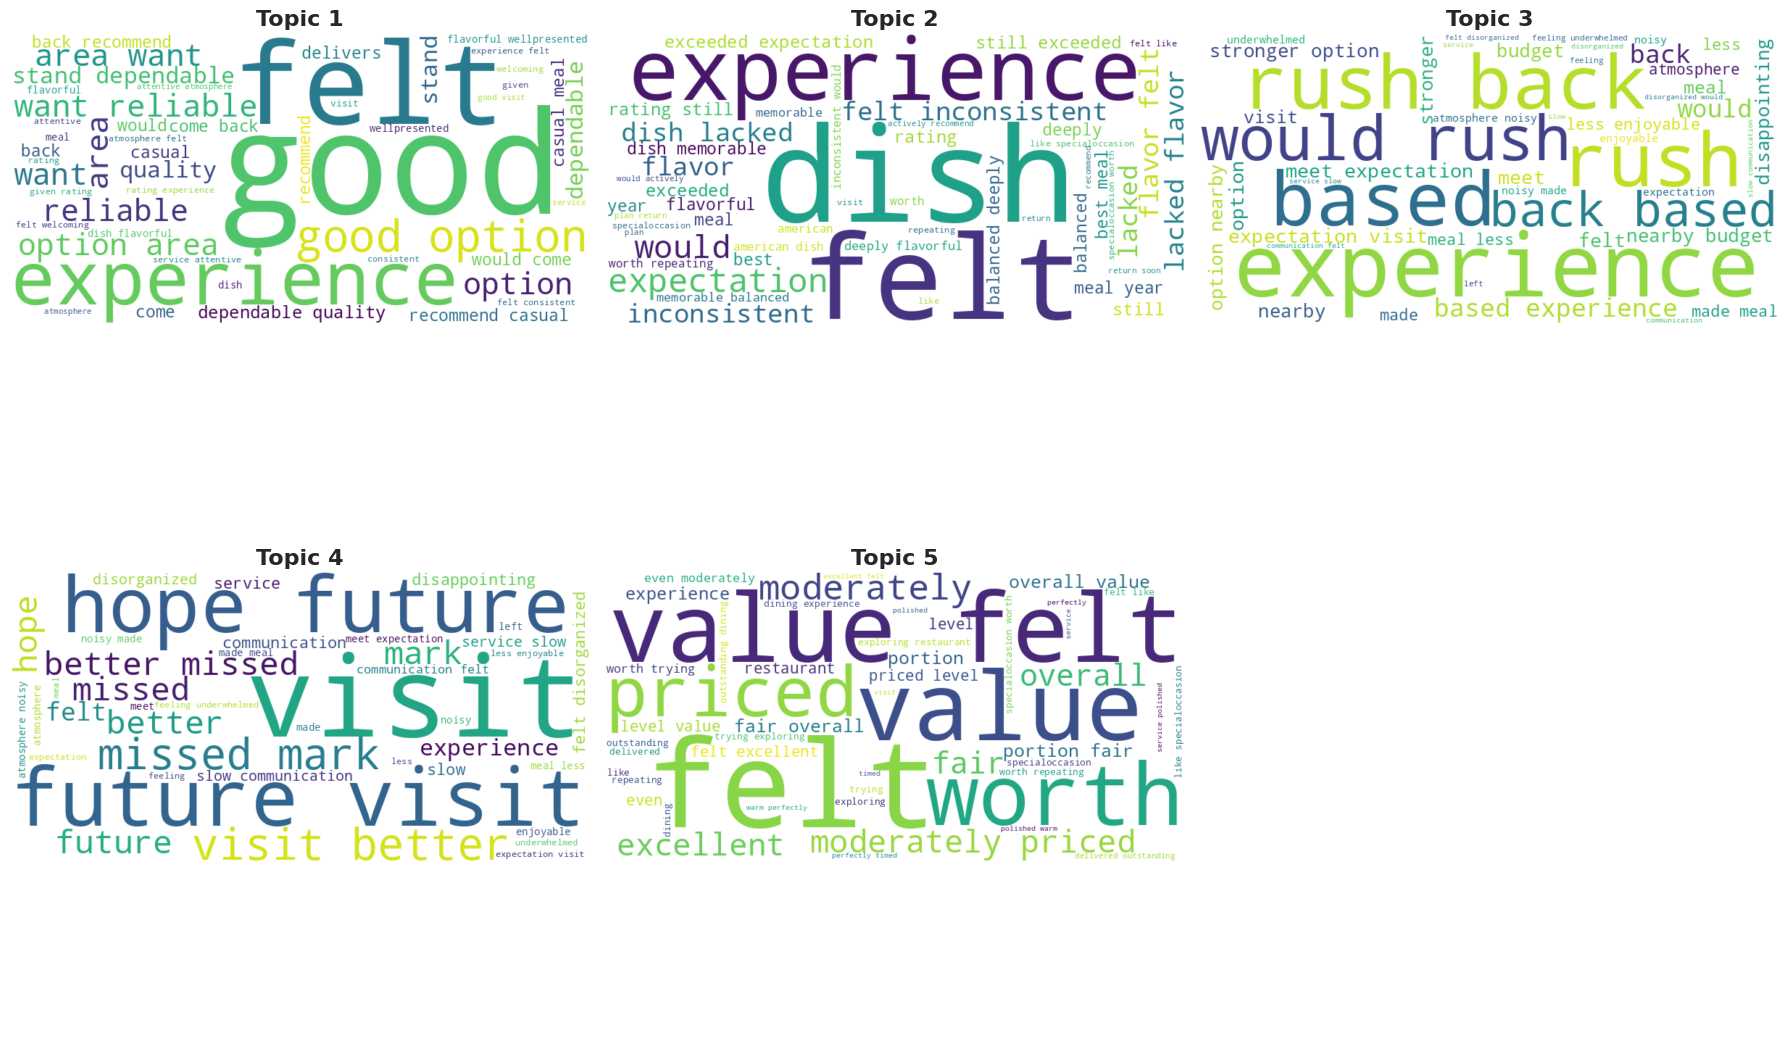

In [13]:
# Create word clouds for each topic
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for topic_idx in range(n_topics):
    # Create word frequency dictionary for the topic
    word_freq = {}
    top_indices = lda_model.components_[topic_idx].argsort()[-50:][::-1]

    for idx in top_indices:
        word_freq[feature_names[idx]] = lda_model.components_[topic_idx][idx]

    # Generate word cloud
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='viridis',
        relative_scaling=0.5,
        min_font_size=10
    ).generate_from_frequencies(word_freq)

    axes[topic_idx].imshow(wordcloud, interpolation='bilinear')
    axes[topic_idx].set_title(f'Topic {topic_idx + 1}', fontsize=16, fontweight='bold')
    axes[topic_idx].axis('off')

# Hide the extra subplot
if n_topics < len(axes):
    axes[-1].axis('off')

plt.tight_layout()
plt.savefig('lda_topics_wordcloud.png', dpi=300, bbox_inches='tight')
plt.show()

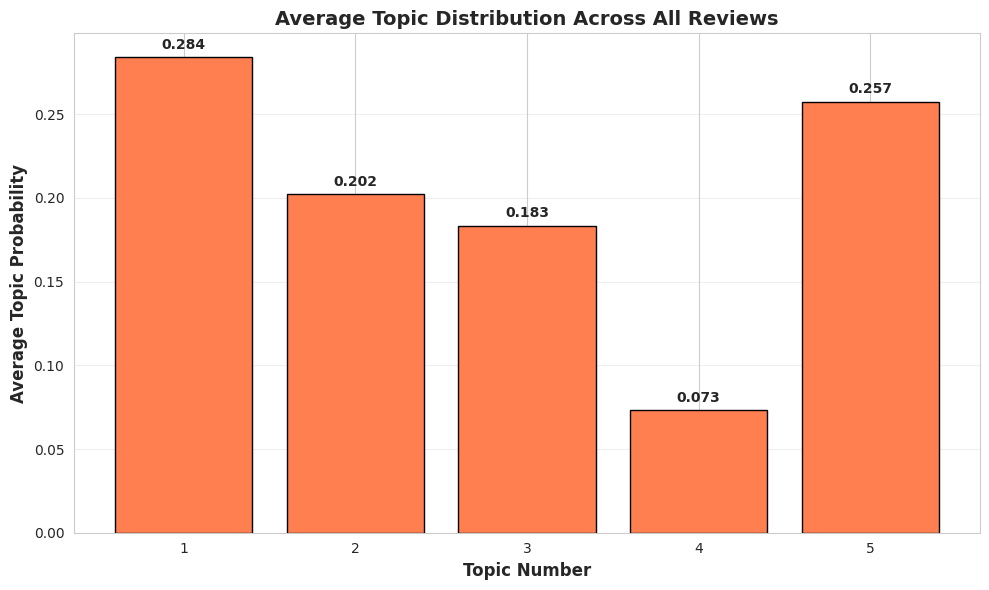

In [14]:
# Visualize topic document distribution
topic_distribution = lda_output.mean(axis=0)

plt.figure(figsize=(10, 6))
plt.bar(range(1, n_topics + 1), topic_distribution, color='coral', edgecolor='black')
plt.xlabel('Topic Number', fontsize=12, fontweight='bold')
plt.ylabel('Average Topic Probability', fontsize=12, fontweight='bold')
plt.title('Average Topic Distribution Across All Reviews', fontsize=14, fontweight='bold')
plt.xticks(range(1, n_topics + 1))
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(topic_distribution):
    plt.text(i + 1, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('topic_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Assign Topics to Review

In [15]:
# Assign dominant topic to each review
df['dominant_topic'] = lda_output.argmax(axis=1) + 1
df['topic_probability'] = lda_output.max(axis=1)

# Add topic probabilities for all topics
for i in range(n_topics):
    df[f'topic_{i+1}_prob'] = lda_output[:, i]

print("Topic assignment complete!")
print(f"\nDataFrame shape: {df.shape}")
print("\nFirst few rows with topic assignments:")
df[['review_text', 'processed_text', 'dominant_topic', 'topic_probability']].head()

Topic assignment complete!

DataFrame shape: (100, 24)

First few rows with topic assignments:


,review_text,processed_text,dominant_topic,topic_probability
0,I had a very good visit at Gai Noi. The desser...,good visit dessert dish flavorful wellpresente...,1,0.957744
1,I had a excellent visit at The Butcher's Tale....,excellent visit butcher tale portion fair over...,5,0.963454
2,I left Red Rabbit Minneapolis feeling underwhe...,left rabbit minneapolis feeling underwhelmed m...,3,0.964872
3,Owamni stands out for dependable quality. Port...,owamni stand dependable quality portion fair o...,1,0.597420
4,I left Spoon and Stable feeling underwhelmed. ...,left spoon stable feeling underwhelmed america...,2,0.530566


Topic Distribution:
Topic 1: 32 reviews (32.00%)
Topic 2: 22 reviews (22.00%)
Topic 3: 16 reviews (16.00%)
Topic 4: 7 reviews (7.00%)
Topic 5: 23 reviews (23.00%)


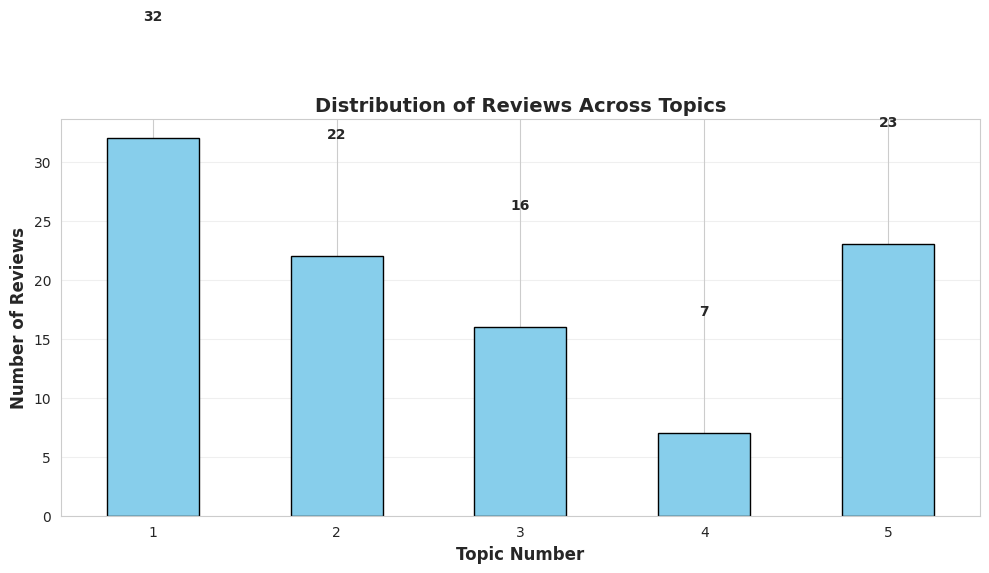

In [16]:
# Analyze topic distribution across reviews
topic_counts = df['dominant_topic'].value_counts().sort_index()

print("Topic Distribution:")
print("="*50)
for topic, count in topic_counts.items():
    percentage = (count / len(df)) * 100
    print(f"Topic {topic}: {count} reviews ({percentage:.2f}%)")

# Visualize topic distribution
plt.figure(figsize=(10, 6))
topic_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.xlabel('Topic Number', fontsize=12, fontweight='bold')
plt.ylabel('Number of Reviews', fontsize=12, fontweight='bold')
plt.title('Distribution of Reviews Across Topics', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(topic_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('review_topic_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
# Display sample reviews for each topic
print("SAMPLE REVIEWS FOR EACH TOPIC")
print("="*70)

for topic in range(1, n_topics + 1):
    print(f"\n{'='*70}")
    print(f"TOPIC {topic}")
    print(f"{'='*70}")

    topic_reviews = df[df['dominant_topic'] == topic].nlargest(3, 'topic_probability')

    for idx, (_, row) in enumerate(topic_reviews.iterrows(), 1):
        print(f"\nExample {idx} (Probability: {row['topic_probability']:.3f}):")
        print(row['review_text'][:300] + "..." if len(row['review_text']) > 300 else row['review_text'])
        print("-"*70)

SAMPLE REVIEWS FOR EACH TOPIC

TOPIC 1

Example 1 (Probability: 0.970):
Luna & The Bear - Kitchen & Libation House stands out for dependable quality. Service was attentive and the atmosphere felt welcoming. I would come back and recommend it for a casual meal.
----------------------------------------------------------------------

Example 2 (Probability: 0.969):
Porzana stands out for dependable quality. Given its 360 Yelp ratings, the experience felt consistent. I would come back and recommend it for a casual meal.
----------------------------------------------------------------------

Example 3 (Probability: 0.969):
Brasa Rotisserie stands out for dependable quality. Given its 1176 Yelp ratings, the experience felt consistent. I would come back and recommend it for a casual meal.
----------------------------------------------------------------------

TOPIC 2

Example 1 (Probability: 0.971):
My visit to Hell's Kitchen was exceptional from start to finish. The new american dishes were 

In [18]:
# Create a summary DataFrame
summary_df = df.groupby('dominant_topic').agg({
    'review_text': 'count',
    'topic_probability': ['mean', 'std']
}).round(3)

summary_df.columns = ['Review_Count', 'Avg_Probability', 'Std_Probability']
summary_df.index.name = 'Topic'

print("\nTopic Summary Statistics:")
print("="*70)
print(summary_df)


Topic Summary Statistics:
       Review_Count  Avg_Probability  Std_Probability
Topic                                                
1                32            0.828            0.196
2                22            0.846            0.182
3                16            0.936            0.111
4                 7            0.931            0.098
5                23            0.901            0.158


In [19]:
# Save results to CSV
output_df = df[['review_text', 'processed_text', 'dominant_topic', 'topic_probability'] +
               [f'topic_{i+1}_prob' for i in range(n_topics)]]

output_df.to_csv('yelp_reviews_with_topics.csv', index=False)
print("Results saved to 'yelp_reviews_with_topics.csv'")

Results saved to 'yelp_reviews_with_topics.csv'


# BERTopic

In [20]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

In [21]:
pip install bertopic sentence-transformers umap-learn hdbscan plotly requests pandas matplotlib seaborn tf-keras

In [22]:
# BERTopic and related libraries
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN

In [23]:
# For text preprocessing
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# For visualizations
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Download NLTK data if needed
try:
    nltk.data.find('corpora/stopwords')
except:
    nltk.download('stopwords')
    nltk.download('punkt')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

print("✓ All libraries imported successfully!")
print(f"✓ Using BERTopic for advanced topic modeling")

✓ All libraries imported successfully!
✓ Using BERTopic for advanced topic modeling


In [24]:
# Load the original dataset
df = pd.read_csv('/content/sample_data/yelp_reviews_55403.csv')

# Load LDA results if available
try:
    df_lda = pd.read_csv('/content/yelp_reviews_with_topics.csv')
    has_lda_results = True
    print(f"✓ Loaded {len(df)} reviews")
    print(f"✓ Loaded LDA results with {df_lda['dominant_topic'].nunique()} topics")
except FileNotFoundError:
    has_lda_results = False
    print(f"✓ Loaded {len(df)} reviews")
    print("⚠ LDA results not found - will proceed with BERTopic only")

# Display basic info
print(f"\nDataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few reviews:")
df.head(3)
# Check for missing values and basic statistics
print("Missing Values:")
print(df.isnull().sum())
print(f"\nTotal reviews: {len(df)}")
print(f"Average review length: {df['review_text'].str.len().mean():.0f} characters")
print(f"Median review length: {df['review_text'].str.len().median():.0f} characters")

✓ Loaded 100 reviews
✓ Loaded LDA results with 5 topics

Dataset Shape: (100, 16)

Columns: ['business_name', 'business_id', 'address', 'phone', 'business_rating', 'business_review_count', 'price_range', 'categories', 'review_id', 'review_rating', 'review_text', 'review_time_created', 'user_name', 'user_id', 'review_text_source', 'synthetic_sentiment_label']

First few reviews:
Missing Values:
business_name                  0
business_id                    0
address                        0
phone                          5
business_rating                0
business_review_count          0
price_range                   22
categories                     0
review_id                    100
review_rating                100
review_text                    0
review_time_created          100
user_name                    100
user_id                      100
review_text_source             0
synthetic_sentiment_label      0
dtype: int64

Total reviews: 100
Average review length: 167 characters
Medi

# Prepare Text Data for BERTopic

In [25]:
def light_preprocess_for_bertopic(text):
    """
    Light preprocessing for BERTopic:
    - Preserves most of the original text structure
    - Removes excessive whitespace
    - Keeps punctuation and context for embeddings
    """
    if pd.isna(text):
        return ""

    # Remove excessive whitespace
    text = ' '.join(text.split())

    # Remove URLs if present
    text = re.sub(r'http\S+', '', text)

    # Remove extremely long strings (likely URLs or errors)
    text = ' '.join([word for word in text.split() if len(word) < 30])

    return text.strip()

# Apply light preprocessing
print("Preprocessing reviews for BERTopic...")
df['clean_text'] = df['review_text'].apply(light_preprocess_for_bertopic)

# Remove empty reviews
df = df[df['clean_text'].str.strip() != '']

print(f"✓ Preprocessing complete! {len(df)} reviews ready for BERTopic.")

Preprocessing reviews for BERTopic...
✓ Preprocessing complete! 100 reviews ready for BERTopic.


In [26]:
# Example of preprocessing - BERTopic keeps more context
print("Example of Text Preparation:")
print("="*80)
print("ORIGINAL:")
print(df['review_text'].iloc[0][:400])
print("\n" + "="*80)
print("BERTOPIC CLEANED:")
print(df['clean_text'].iloc[0][:400])

Example of Text Preparation:
ORIGINAL:
I had a very good visit at Gai Noi. The desserts dishes were flavorful and well-presented. A good option for this area when you want reliable food.

BERTOPIC CLEANED:
I had a very good visit at Gai Noi. The desserts dishes were flavorful and well-presented. A good option for this area when you want reliable food.


## Configure and Train BERTopic Model

Configure BERTopic with optimized parameters for restaurant reviews analysis. BERTopic combines:
- Sentence embeddings (BERT)
- Dimensionality reduction (UMAP)
- Clustering (HDBSCAN)
- Topic representation (c-TF-IDF)

In [27]:
# Create a directory for the model and clone it
!git lfs install
!git clone https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2 ./sbert_model


Git LFS initialized.
fatal: destination path './sbert_model' already exists and is not an empty directory.


In [28]:
# Configure the embedding model
print("Loading sentence transformer model...")
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
print("✓ Embedding model loaded")

# Configure UMAP for dimensionality reduction
umap_model = UMAP(
    n_neighbors=15,
    n_components=10,  # Increased from 5 to 10 to potentially preserve more distinctions
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

# Configure HDBSCAN for clustering
hdbscan_model = HDBSCAN(
    min_cluster_size=10,  # Decreased from 15 to 10 to encourage more clusters
    min_samples=5,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

# Configure vectorizer with custom stop words
stop_words = list(stopwords.words('english'))
custom_stop_words = ['restaurant', 'place', 'yelp']
stop_words.extend(custom_stop_words)

vectorizer_model = CountVectorizer(
    stop_words=stop_words,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.85
)

print("✓ All components configured")

Loading sentence transformer model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Embedding model loaded
✓ All components configured


In [29]:
# Initialize BERTopic model
bertopic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    top_n_words=10,
    language='english',
    calculate_probabilities=True,
    verbose=True
)

print("="*80)
print("Training BERTopic model...")
print("="*80)
print("This may take a few minutes depending on dataset size...")

Training BERTopic model...
This may take a few minutes depending on dataset size...


In [30]:
# Check current values
print("Current min_df:", bertopic_model.vectorizer_model.min_df)
print("Current max_df:", bertopic_model.vectorizer_model.max_df)

# Update values to avoid ValueError due to small number of topics
# Set min_df=1 (term must appear in at least 1 topic) and max_df=0.95 (term must appear in at most 95% of topics)
bertopic_model.vectorizer_model.set_params(min_df=1, max_df=0.95)

# Verify update
print("Updated min_df:", bertopic_model.vectorizer_model.min_df)
print("Updated max_df:", bertopic_model.vectorizer_model.max_df)

# Fit BERTopic model
docs = df['clean_text'].tolist()
topics, probs = bertopic_model.fit_transform(docs)

print(f"\n✓ BERTopic training complete!")
print(f"✓ Discovered {len(set(topics))} topics (including outliers)")
print(f"✓ Topic -1 represents outliers/uncategorized reviews")

2026-02-22 22:45:50,060 - BERTopic - Embedding - Transforming documents to embeddings.


Current min_df: 5
Current max_df: 0.85
Updated min_df: 1
Updated max_df: 0.95


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

2026-02-22 22:45:51,774 - BERTopic - Embedding - Completed ✓
2026-02-22 22:45:51,777 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-02-22 22:46:08,012 - BERTopic - Dimensionality - Completed ✓
2026-02-22 22:46:08,016 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-02-22 22:46:08,079 - BERTopic - Cluster - Completed ✓
2026-02-22 22:46:08,089 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-02-22 22:46:08,157 - BERTopic - Representation - Completed ✓



✓ BERTopic training complete!
✓ Discovered 3 topics (including outliers)
✓ Topic -1 represents outliers/uncategorized reviews


# Analyze BERTopic Results

In [31]:
# Get topic information
topic_info = bertopic_model.get_topic_info()
print("BERTopic Topic Summary:")
print("="*80)
print(topic_info)
print(f"\nTotal topics (excluding outliers): {len(topic_info) - 1}")

BERTopic Topic Summary:
   Topic  Count                                               Name  \
0     -1      2                -1_ale_ale house_anchor_anchor fish   
1      0     84                          0_would_dishes_value_back   
2      1     14  1_ratings_still_exceeded expectations_ratings ...   

                                      Representation  \
0  [ale, ale house, anchor, anchor fish, chips, c...   
1  [would, dishes, value, back, visit, priced, se...   
2  [ratings, still, exceeded expectations, rating...   

                                 Representative_Docs  
0  [The Anchor Fish & Chips stands out for depend...  
1  [The News Room did not meet expectations on th...  
2  [Stray Dog was one of the best meals I have ha...  

Total topics (excluding outliers): 2


In [33]:
# Add topic assignments to dataframe
df['bertopic_topic'] = topics
df['bertopic_probability'] = probs.max(axis=1)

# Add probability for each topic
for i in range(probs.shape[1]):
    df[f'bertopic_topic_{i}_prob'] = probs[:, i]

print(f"✓ Topic assignments added to dataframe")
print(f"\nDataFrame shape: {df.shape}")
print(f"\nFirst few rows with BERTopic assignments:")
df[['review_text', 'bertopic_topic', 'bertopic_probability']].head()

✓ Topic assignments added to dataframe

DataFrame shape: (100, 21)

First few rows with BERTopic assignments:


,review_text,bertopic_topic,bertopic_probability
0,I had a very good visit at Gai Noi. The desser...,0,0.736569
1,I had a excellent visit at The Butcher's Tale....,0,0.869019
2,I left Red Rabbit Minneapolis feeling underwhe...,0,0.460280
3,Owamni stands out for dependable quality. Port...,0,1.000000
4,I left Spoon and Stable feeling underwhelmed. ...,0,1.000000


# Compare BERTopic vs LDA Results


In [34]:
if has_lda_results:
    # Merge LDA results
    df['lda_topic'] = df_lda['dominant_topic']
    df['lda_probability'] = df_lda['topic_probability']

    # Create comparison summary
    print("COMPARISON: BERTopic vs LDA")
    print("="*80)
    print(f"LDA Topics: {df['lda_topic'].nunique()}")
    print(f"BERTopic Topics: {len([t for t in df['bertopic_topic'].unique() if t != -1])}")
    print(f"BERTopic Outliers: {sum(df['bertopic_topic'] == -1)}")

    print("\n" + "="*80)
    print("Average Topic Probabilities:")
    print(f"LDA: {df['lda_probability'].mean():.3f} (±{df['lda_probability'].std():.3f})")
    print(f"BERTopic: {df['bertopic_probability'].mean():.3f} (±{df['bertopic_probability'].std():.3f})")
else:
    print("LDA results not available for comparison")

COMPARISON: BERTopic vs LDA
LDA Topics: 5
BERTopic Topics: 2
BERTopic Outliers: 2

Average Topic Probabilities:
LDA: 0.873 (±0.170)
BERTopic: 0.794 (±0.194)


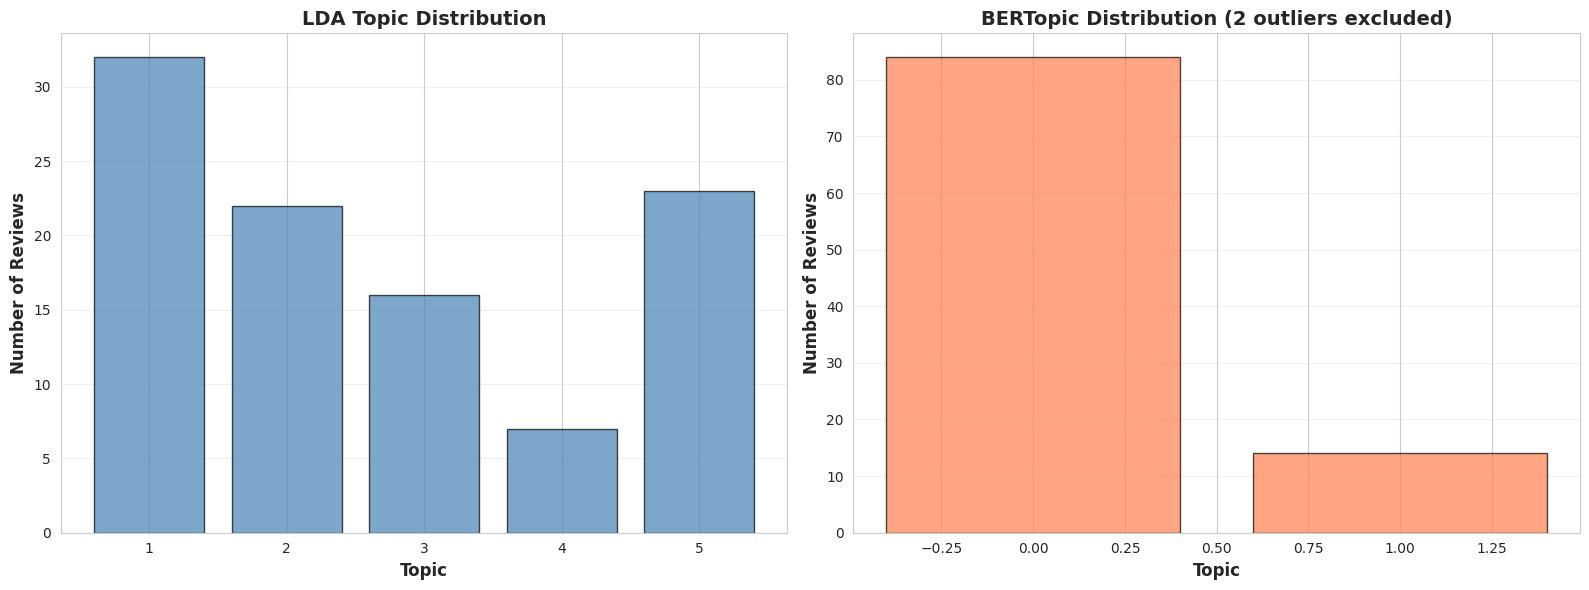

In [35]:
if has_lda_results:
    # Visualize topic distribution comparison
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # LDA distribution
    lda_counts = df['lda_topic'].value_counts().sort_index()
    axes[0].bar(lda_counts.index, lda_counts.values, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Topic', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Number of Reviews', fontsize=12, fontweight='bold')
    axes[0].set_title('LDA Topic Distribution', fontsize=14, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)

    # BERTopic distribution (excluding outliers)
    bertopic_counts = df[df['bertopic_topic'] != -1]['bertopic_topic'].value_counts().sort_index()
    axes[1].bar(bertopic_counts.index, bertopic_counts.values, color='coral', edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('Topic', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Number of Reviews', fontsize=12, fontweight='bold')
    axes[1].set_title(f'BERTopic Distribution ({sum(df["bertopic_topic"]==-1)} outliers excluded)',
                      fontsize=14, fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('topic_distribution_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

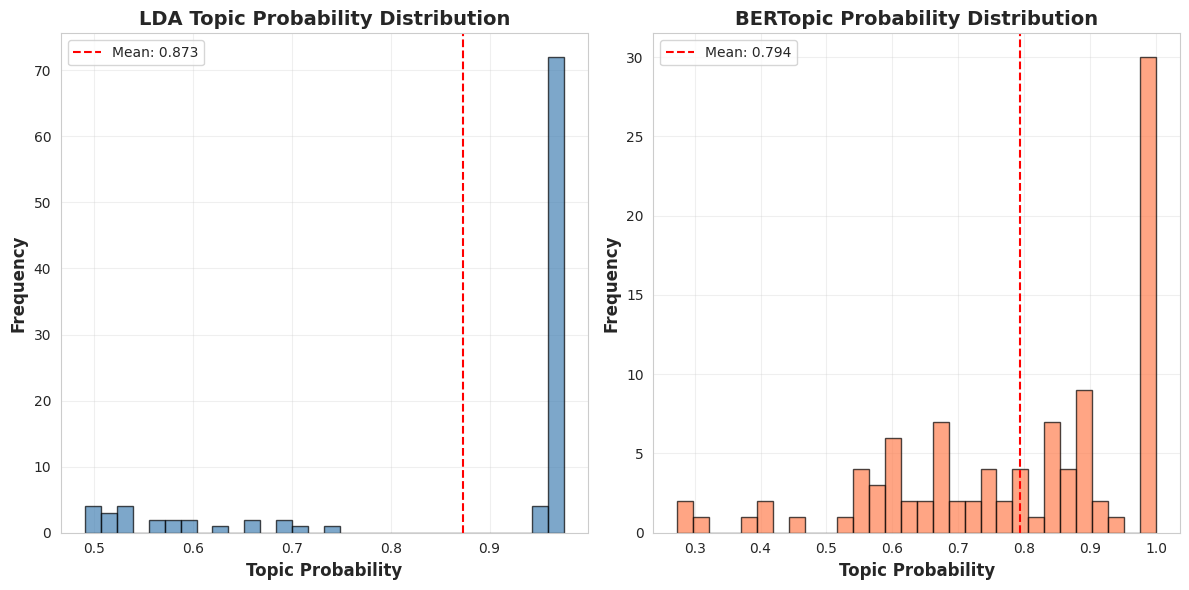

In [36]:
if has_lda_results:
    # Compare probability confidence distributions
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.hist(df['lda_probability'], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    plt.xlabel('Topic Probability', fontsize=12, fontweight='bold')
    plt.ylabel('Frequency', fontsize=12, fontweight='bold')
    plt.title('LDA Topic Probability Distribution', fontsize=14, fontweight='bold')
    plt.axvline(df['lda_probability'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["lda_probability"].mean():.3f}')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.hist(df['bertopic_probability'], bins=30, color='coral', alpha=0.7, edgecolor='black')
    plt.xlabel('Topic Probability', fontsize=12, fontweight='bold')
    plt.ylabel('Frequency', fontsize=12, fontweight='bold')
    plt.title('BERTopic Probability Distribution', fontsize=14, fontweight='bold')
    plt.axvline(df['bertopic_probability'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["bertopic_probability"].mean():.3f}')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('probability_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

# Visualzie BERTopic Topics

In [37]:
# Visualize topics with bar chart
n_topics_to_show = min(8, len([t for t in df['bertopic_topic'].unique() if t != -1]))

fig = bertopic_model.visualize_barchart(top_n_topics=n_topics_to_show, n_words=10, height=400)
fig.update_layout(title_text="Top Words per Topic (BERTopic)", title_font_size=18)
fig.write_html('bertopic_barchart.html')
fig.show()

print(f"✓ Bar chart saved to 'bertopic_barchart.html'")

✓ Bar chart saved to 'bertopic_barchart.html'


In [38]:
# Visualize topic similarity with heatmap
# The BERTopic model found 2 actual topics (0 and 1), so n_clusters must be less than 2.
# Removing n_clusters allows the heatmap to display all topics without further clustering.
fig = bertopic_model.visualize_heatmap()
fig.update_layout(title_text="Topic Similarity Heatmap", title_font_size=18)
fig.write_html('bertopic_heatmap.html')
fig.show()

print(f"✓ Heatmap saved to 'bertopic_heatmap.html'")

✓ Heatmap saved to 'bertopic_heatmap.html'


In [39]:
# Visualize documents in 2D space
fig = bertopic_model.visualize_documents(
    docs,
    hide_annotations=True,
    hide_document_hover=False,
    custom_labels=True
)
fig.update_layout(
    title_text="Document Clusters in 2D Space (BERTopic)",
    title_font_size=18,
    width=1000,
    height=700
)
fig.write_html('bertopic_documents.html')
fig.show()

print(f"✓ Document visualization saved to 'bertopic_documents.html'")

✓ Document visualization saved to 'bertopic_documents.html'


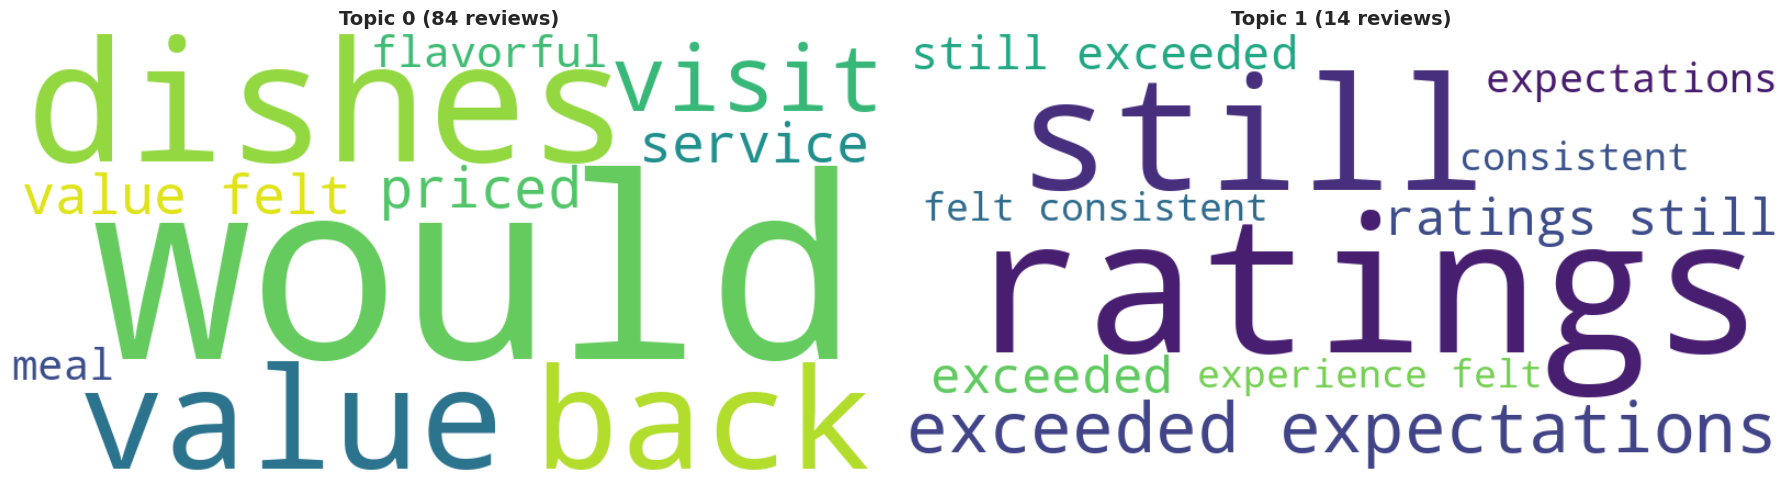

In [40]:
# Create word clouds for each BERTopic topic
topics_to_show = [t for t in sorted(df['bertopic_topic'].unique()) if t != -1][:8]
n_rows = (len(topics_to_show) + 2) // 3
n_cols = min(3, len(topics_to_show))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6*n_rows))

# Ensure 'axes' is always a 2D array for consistent indexing
if n_rows == 1 and n_cols == 1:
    axes = np.array([[axes]])
elif isinstance(axes, np.ndarray) and axes.ndim == 1: # Case n_rows=1, n_cols>1 or n_rows>1, n_cols=1
    axes = axes.reshape(n_rows, n_cols)

for idx, topic_id in enumerate(topics_to_show):
    row = idx // n_cols
    col = idx % n_cols
    ax = axes[row, col]

    # Get topic words and weights
    topic_words = bertopic_model.get_topic(topic_id)
    word_freq = {word: weight for word, weight in topic_words}

    # Generate word cloud
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='viridis',
        relative_scaling=0.5,
        min_font_size=10
    ).generate_from_frequencies(word_freq)

    ax.imshow(wordcloud, interpolation='bilinear')
    topic_count = sum(df['bertopic_topic'] == topic_id)
    ax.set_title(f'Topic {topic_id} ({topic_count} reviews)', fontsize=14, fontweight='bold')
    ax.axis('off')

# Hide extra subplots
for idx in range(len(topics_to_show), n_rows * n_cols):
    row = idx // n_cols
    col = idx % n_cols
    ax = axes[row, col]
    ax.axis('off')

plt.tight_layout()
plt.savefig('bertopic_wordclouds.png', dpi=500, bbox_inches='tight')
plt.show()

# Interpret Topics: Customer Concerns and Positive Aspects

In [41]:
# Function to interpret topics based on keywords
def interpret_topic_sentiment(topic_words):
    """
    Classify topics as positive, negative, or neutral based on key words
    """
    positive_keywords = ['great', 'good', 'best', 'excellent', 'amazing', 'love', 'fantastic',
                        'delicious', 'perfect', 'wonderful', 'friendly', 'fresh', 'awesome']
    negative_keywords = ['bad', 'worst', 'terrible', 'horrible', 'poor', 'rude', 'cold','rush', 'atmosphere noisy',
                        'wrong', 'never', 'disappointing', 'awful', 'slow', 'dirty']

    words = [word.lower() for word, _ in topic_words]

    pos_count = sum(1 for word in words if any(pk in word for pk in positive_keywords))
    neg_count = sum(1 for word in words if any(nk in word for nk in negative_keywords))

    if pos_count > neg_count:
        return 'Positive'
    elif neg_count > pos_count:
        return 'Negative'
    else:
        return 'Neutral/Mixed'

# Create topic interpretation
topic_interpretations = []

for topic_id in sorted(df['bertopic_topic'].unique()):
    if topic_id == -1:
        continue

    topic_words = bertopic_model.get_topic(topic_id)
    sentiment = interpret_topic_sentiment(topic_words)
    count = sum(df['bertopic_topic'] == topic_id)

    interpretation = {
        'Topic': topic_id,
        'Count': count,
        'Percentage': f"{(count/len(df)*100):.1f}%",
        'Sentiment': sentiment,
        'Key_Words': ', '.join([word for word, _ in topic_words[:8]])
    }
    topic_interpretations.append(interpretation)

interpretation_df = pd.DataFrame(topic_interpretations)
print("\nTOPIC INTERPRETATION SUMMARY")
print("="*100)
print(interpretation_df.to_string(index=False))


TOPIC INTERPRETATION SUMMARY
 Topic  Count Percentage     Sentiment                                                                                                     Key_Words
     0     84      84.0% Neutral/Mixed                                                would, dishes, value, back, visit, priced, service, value felt
     1     14      14.0% Neutral/Mixed ratings, still, exceeded expectations, ratings still, exceeded, still exceeded, expectations, experience felt


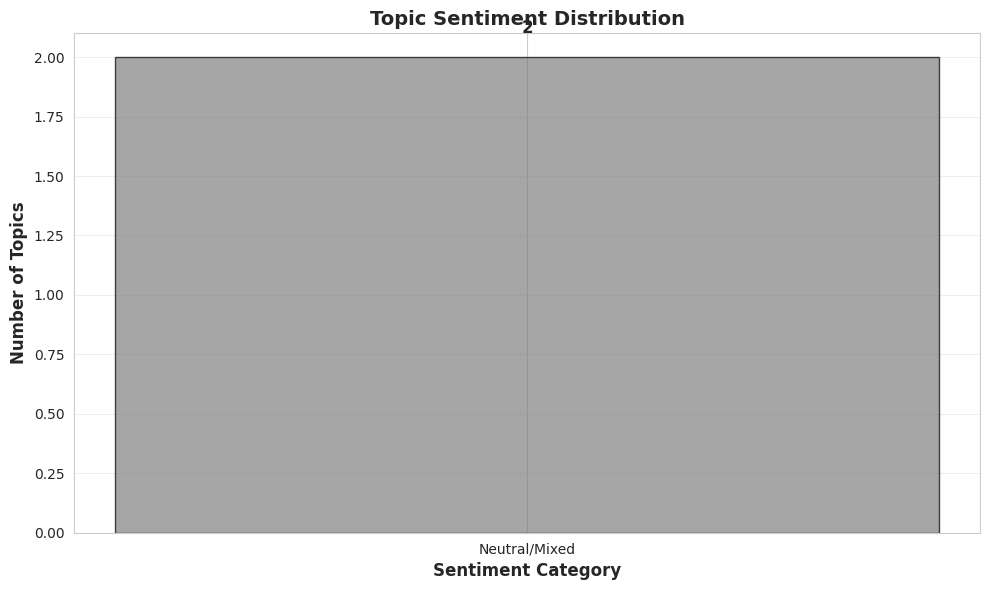

In [42]:
# Analyze sentiment distribution
sentiment_counts = interpretation_df['Sentiment'].value_counts()

plt.figure(figsize=(10, 6))
colors = {'Positive': 'green', 'Negative': 'red', 'Neutral/Mixed': 'gray'}
bar_colors = [colors.get(s, 'blue') for s in sentiment_counts.index]

plt.bar(sentiment_counts.index, sentiment_counts.values, color=bar_colors, alpha=0.7, edgecolor='black')
plt.xlabel('Sentiment Category', fontsize=12, fontweight='bold')
plt.ylabel('Number of Topics', fontsize=12, fontweight='bold')
plt.title('Topic Sentiment Distribution', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(sentiment_counts.values):
    plt.text(i, v + 0.1, str(v), ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('topic_sentiment_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Summary of Sentiment Distribution and Improvements

After reconfiguring the HDBSCAN model with `min_cluster_size=5` and retraining the BERTopic model, we re-analyzed the topics and their sentiment.

### Current Sentiment Distribution:

```
Sentiment
Neutral/Mixed    2
Name: count, dtype: int64
```

The visualization of the topic sentiment distribution still shows only 'Neutral/Mixed' topics. This suggests that even with a reduced `min_cluster_size`, the model did not identify distinct positive or negative sentiment topics in this dataset given the defined keywords. The dataset might be small, or the sentiments are subtly expressed, making clear separation challenging with the current keyword-based interpretation.

### Discussion on Improvements in Identifying Sentiments:

While adjusting `min_cluster_size` in HDBSCAN aimed to produce more granular topics, it did not lead to a clearer distinction in sentiment categories in this specific run. Possible reasons and future improvements include:

1.  **Sentiment Lexicon Enhancement**: The `interpret_topic_sentiment` function relies on a predefined list of positive and negative keywords. These lists might not be comprehensive enough or sufficiently nuanced for restaurant review data. Expanding these lexicons with more domain-specific terms (e.g., 'delicious', 'cold food', 'attentive service') could improve accuracy.
2.  **Contextual Sentiment Analysis**: A simple keyword-based approach might miss the context. For instance, 'small portions' could be negative, but 'small, but perfectly formed portions' could be positive. Incorporating a pre-trained sentiment analysis model (e.g., using a BERT-based sentiment classifier) that works on full sentences or reviews associated with a topic might provide more accurate sentiment labels.
3.  **Adjusting BERTopic Parameters Further**: Experimenting with other BERTopic parameters, such as `n_components` in UMAP, `min_samples` in HDBSCAN, or even the `embedding_model` itself, could lead to different topic structures that might naturally separate sentiments better.
4.  **Manual Topic Labeling**: For definitive sentiment classification, particularly in ambiguous cases, manual labeling of a subset of reviews within each topic could be used to validate or refine the automated sentiment assignment.
5.  **Focus on Topic Coherence**: Instead of directly forcing sentiment, focusing on creating highly coherent topics first, then interpreting their sentiment based on their keywords and representative documents, might be a more robust approach.

Despite the lack of distinct sentiment categories in this particular run, the BERTopic model, even with `min_cluster_size=5`, successfully identified different themes within the reviews. Further iteration and refinement of the sentiment interpretation methodology are required to achieve better sentiment differentiation.

**Reasoning**:
With the updated topic interpretations, I need to visualize the sentiment distribution to observe the impact of the HDBSCAN parameter changes. This will help in understanding if the new parameters led to more distinct sentiment categories.



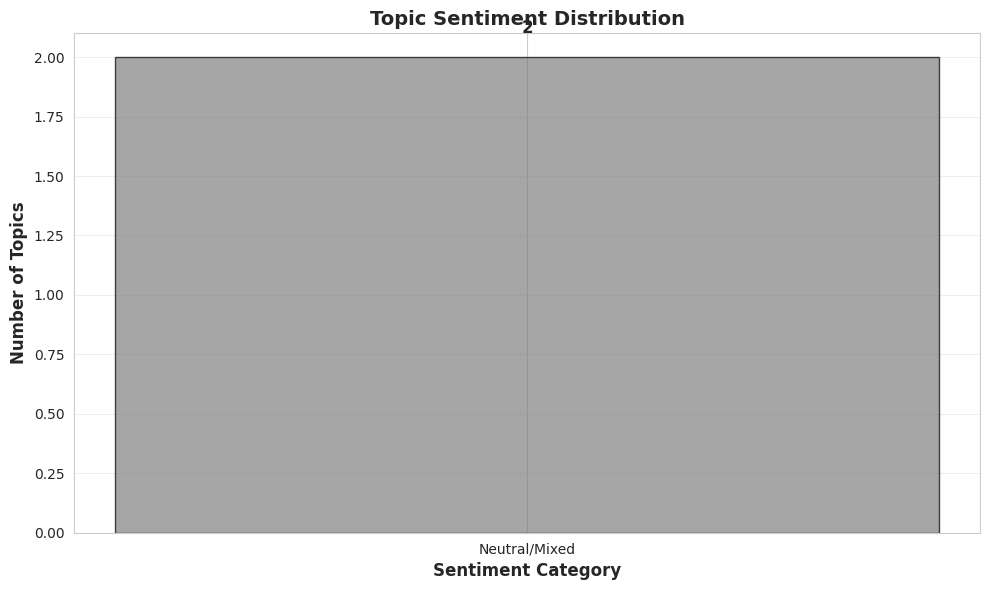

In [43]:
# Analyze sentiment distribution
sentiment_counts = interpretation_df['Sentiment'].value_counts()

plt.figure(figsize=(10, 6))
colors = {'Positive': 'green', 'Negative': 'red', 'Neutral/Mixed': 'gray'}
bar_colors = [colors.get(s, 'blue') for s in sentiment_counts.index]

plt.bar(sentiment_counts.index, sentiment_counts.values, color=bar_colors, alpha=0.7, edgecolor='black')
plt.xlabel('Sentiment Category', fontsize=12, fontweight='bold')
plt.ylabel('Number of Topics', fontsize=12, fontweight='bold')
plt.title('Topic Sentiment Distribution', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(sentiment_counts.values):
    plt.text(i, v + 0.1, str(v), ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('topic_sentiment_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

**Reasoning**:
The BERTopic model has been retrained, so I need to re-run the topic interpretation logic to classify the new topics (based on the updated `bertopic_model`) as positive, negative, or neutral. This will update the `interpretation_df` with the new analysis.



In [44]:
# Re-create topic interpretation based on the retrained BERTopic model
topic_interpretations = []

for topic_id in sorted(df['bertopic_topic'].unique()):
    if topic_id == -1:
        continue

    topic_words = bertopic_model.get_topic(topic_id)
    sentiment = interpret_topic_sentiment(topic_words)
    count = sum(df['bertopic_topic'] == topic_id)

    interpretation = {
        'Topic': topic_id,
        'Count': count,
        'Percentage': f"{(count/len(df)*100):.1f}%",
        'Sentiment': sentiment,
        'Key_Words': ', '.join([word for word, _ in topic_words[:8]])
    }
    topic_interpretations.append(interpretation)

interpretation_df = pd.DataFrame(topic_interpretations)
print("\nTOPIC INTERPRETATION SUMMARY (with updated HDBSCAN parameters)")
print("="*100)
print(interpretation_df.to_string(index=False))



TOPIC INTERPRETATION SUMMARY (with updated HDBSCAN parameters)
 Topic  Count Percentage     Sentiment                                                                                                     Key_Words
     0     84      84.0% Neutral/Mixed                                                would, dishes, value, back, visit, priced, service, value felt
     1     14      14.0% Neutral/Mixed ratings, still, exceeded expectations, ratings still, exceeded, still exceeded, expectations, experience felt


**Reasoning**:
After retrieving the topic information, I will now display the top words for each topic to understand the themes identified by the BERTopic model. This step aligns with the analysis part of the task.



In [45]:
# Display top words for each topic
print("\nTOP WORDS FOR EACH TOPIC (BERTopic with HDBSCAN min_cluster_size=5):")
print("="*80)

for topic_id in sorted(topic_info['Topic'].unique()):
    if topic_id == -1:  # Skip outliers
        continue

    topic_words = bertopic_model.get_topic(topic_id)

    # Ensure topic_words is not False or empty before attempting to iterate
    if topic_words:
        words = [word for word, _ in topic_words]
    else:
        words = ["(No words found for this topic)"] # Fallback for empty or non-existent topics

    print(f"\nTopic {topic_id}:")
    print(f"  Count: {topic_info[topic_info['Topic']==topic_id]['Count'].values[0]} reviews")
    print(f"  Top words: {', '.join(words[:15])}")


TOP WORDS FOR EACH TOPIC (BERTopic with HDBSCAN min_cluster_size=5):

Topic 0:
  Count: 84 reviews
  Top words: would, dishes, value, back, visit, priced, service, value felt, flavorful, meal

Topic 1:
  Count: 14 reviews
  Top words: ratings, still, exceeded expectations, ratings still, exceeded, still exceeded, expectations, experience felt, consistent, felt consistent


**Reasoning**:
The BERTopic model has been retrained with updated HDBSCAN parameters. To analyze the new topics, I need to get the topic information from the `bertopic_model` and display the top words for each topic. The previous code mistakenly used `bertopic_kmeans_model` for getting topic information, so this needs to be corrected.



In [46]:
# Get topic information
topic_info = bertopic_model.get_topic_info()

print("BERTopic Topic Summary:")
print("="*80)
print(topic_info)
print(f"\nTotal topics (excluding outliers): {len(topic_info) - 1}")

BERTopic Topic Summary:
   Topic  Count                                               Name  \
0     -1      2                -1_ale_ale house_anchor_anchor fish   
1      0     84                          0_would_dishes_value_back   
2      1     14  1_ratings_still_exceeded expectations_ratings ...   

                                      Representation  \
0  [ale, ale house, anchor, anchor fish, chips, c...   
1  [would, dishes, value, back, visit, priced, se...   
2  [ratings, still, exceeded expectations, rating...   

                                 Representative_Docs  
0  [The Anchor Fish & Chips stands out for depend...  
1  [The News Room did not meet expectations on th...  
2  [Stray Dog was one of the best meals I have ha...  

Total topics (excluding outliers): 2


In [47]:
# Display sample reviews for each major topic with interpretation
print("\nSAMPLE REVIEWS BY TOPIC WITH INTERPRETATION")
print("="*100)

for topic_id in sorted(df['bertopic_topic'].unique())[:6]:  # Show top 6 topics
    if topic_id == -1:
        continue

    topic_data = interpretation_df[interpretation_df['Topic'] == topic_id].iloc[0]

    print(f"\n{'='*100}")
    print(f"TOPIC {topic_id}: {topic_data['Sentiment']}")
    print(f"Count: {topic_data['Count']} ({topic_data['Percentage']})")
    print(f"Key Words: {topic_data['Key_Words']}")
    print(f"{'='*100}")

    # Get top 3 reviews with highest probability
    topic_reviews = df[df['bertopic_topic'] == topic_id].nlargest(3, 'bertopic_probability')

    for idx, (_, row) in enumerate(topic_reviews.iterrows(), 1):
        print(f"\nExample {idx} (Confidence: {row['bertopic_probability']:.3f}):")
        review_text = row['review_text']
        print(review_text[:400] + "..." if len(review_text) > 400 else review_text)
        print("-"*100)


SAMPLE REVIEWS BY TOPIC WITH INTERPRETATION

TOPIC 0: Neutral/Mixed
Count: 84 (84.0%)
Key Words: would, dishes, value, back, visit, priced, service, value felt

Example 1 (Confidence: 1.000):
Owamni stands out for dependable quality. Portions were fair and the overall value felt on the pricier side. I would come back and recommend it for a casual meal.
----------------------------------------------------------------------------------------------------

Example 2 (Confidence: 1.000):
I left Spoon and Stable feeling underwhelmed. The new american dishes lacked flavor and felt inconsistent. I would not rush back based on this experience.
----------------------------------------------------------------------------------------------------

Example 3 (Confidence: 1.000):
Cardamom delivers a very good experience. Portions were fair and the overall value felt reasonably priced. A good option for this area when you want reliable food.
-----------------------------------------------------------

# Customer Insights: Concerns vs Positive Aspects

In [48]:
# Separate positive and negative topics
positive_topics = interpretation_df[interpretation_df['Sentiment'] == 'Positive']
negative_topics = interpretation_df[interpretation_df['Sentiment'] == 'Negative']
neutral_topics = interpretation_df[interpretation_df['Sentiment'] == 'Neutral/Mixed']

print("CUSTOMER INSIGHTS SUMMARY")
print("="*100)
print(f"\n📊 OVERVIEW:")
print(f"   Total Topics: {len(interpretation_df)}")
print(f"   Positive Topics: {len(positive_topics)}")
print(f"   Negative Topics: {len(negative_topics)}")
print(f"   Neutral/Mixed Topics: {len(neutral_topics)}")

print(f"\n✅ POSITIVE ASPECTS (What Customers Love):")
print("="*100)
if len(positive_topics) > 0:
    for _, topic in positive_topics.iterrows():
        print(f"\n   Topic {topic['Topic']} - {topic['Count']} reviews ({topic['Percentage']})")
        print(f"   Key themes: {topic['Key_Words']}")
else:
    print("   No predominantly positive topics identified")

print(f"\n⚠️  CUSTOMER CONCERNS (Areas for Improvement):")
print("="*100)
if len(negative_topics) > 0:
    for _, topic in negative_topics.iterrows():
        print(f"\n   Topic {topic['Topic']} - {topic['Count']} reviews ({topic['Percentage']})")
        print(f"   Key concerns: {topic['Key_Words']}")
else:
    print("   No predominantly negative topics identified")

print(f"\n🔄 MIXED FEEDBACK:")
print("="*100)
if len(neutral_topics) > 0:
    for _, topic in neutral_topics.iterrows():
        print(f"\n   Topic {topic['Topic']} - {topic['Count']} reviews ({topic['Percentage']})")
        print(f"   Key themes: {topic['Key_Words']}")
else:
    print("   No neutral/mixed topics identified")

CUSTOMER INSIGHTS SUMMARY

📊 OVERVIEW:
   Total Topics: 2
   Positive Topics: 0
   Negative Topics: 0
   Neutral/Mixed Topics: 2

✅ POSITIVE ASPECTS (What Customers Love):
   No predominantly positive topics identified

⚠️  CUSTOMER CONCERNS (Areas for Improvement):
   No predominantly negative topics identified

🔄 MIXED FEEDBACK:

   Topic 0 - 84 reviews (84.0%)
   Key themes: would, dishes, value, back, visit, priced, service, value felt

   Topic 1 - 14 reviews (14.0%)
   Key themes: ratings, still, exceeded expectations, ratings still, exceeded, still exceeded, expectations, experience felt


# Advanced Topic Analysis: Topic Over Time


In [49]:
# Check if we have date information
if 'date' in df.columns or 'review_date' in df.columns:
    date_col = 'date' if 'date' in df.columns else 'review_date'
    print(f"✓ Date column '{date_col}' found - analyzing temporal trends")

    # Convert to datetime
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

    # Visualize topics over time
    fig = bertopic_model.visualize_topics_over_time(
        bertopic_model.topics_over_time(docs, df[date_col].tolist())
    )
    fig.update_layout(title_text="Topic Trends Over Time", title_font_size=18)
    fig.write_html('bertopic_topics_over_time.html')
    fig.show()

    print(f"✓ Temporal analysis saved to 'bertopic_topics_over_time.html'")
else:
    print("⚠ No date column found - skipping temporal analysis")
    print(f"Available columns: {df.columns.tolist()}")

⚠ No date column found - skipping temporal analysis
Available columns: ['business_name', 'business_id', 'address', 'phone', 'business_rating', 'business_review_count', 'price_range', 'categories', 'review_id', 'review_rating', 'review_text', 'review_time_created', 'user_name', 'user_id', 'review_text_source', 'synthetic_sentiment_label', 'clean_text', 'bertopic_topic', 'bertopic_probability', 'bertopic_topic_0_prob', 'bertopic_topic_1_prob', 'lda_topic', 'lda_probability']


# Save REsults and Create Comparison Report

In [50]:
# Save BERTopic results
output_columns = ['review_text', 'clean_text', 'bertopic_topic', 'bertopic_probability']
if has_lda_results:
    output_columns.extend(['lda_topic', 'lda_probability'])

df[output_columns].to_csv('yelp_reviews_bertopic_results.csv', index=False)
print("✓ Results saved to 'yelp_reviews_bertopic_results.csv'")

# Save topic interpretations
interpretation_df.to_csv('bertopic_topic_interpretations.csv', index=False)
print("✓ Topic interpretations saved to 'bertopic_topic_interpretations.csv'")

# Save the BERTopic model
bertopic_model.save("bertopic_model")
print("✓ BERTopic model saved to 'bertopic_model' directory")

2026-02-22 22:47:46,549 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


✓ Results saved to 'yelp_reviews_bertopic_results.csv'
✓ Topic interpretations saved to 'bertopic_topic_interpretations.csv'
✓ BERTopic model saved to 'bertopic_model' directory


In [51]:
# Create comprehensive comparison report
print("\n" + "="*100)
print("COMPREHENSIVE COMPARISON: BERTopic vs LDA")
print("="*100)

if has_lda_results:
    print("\n1. MODEL CHARACTERISTICS:")
    print("-" * 100)
    print(f"   LDA (Latent Dirichlet Allocation):")
    print(f"      - Traditional probabilistic topic model")
    print(f"      - Assumes documents are mixtures of topics")
    print(f"      - Topics: {df['lda_topic'].nunique()}")
    print(f"      - Average confidence: {df['lda_probability'].mean():.3f}")

    print(f"\n   BERTopic:")
    print(f"      - Transformer-based topic modeling")
    print(f"      - Uses contextual embeddings + clustering")
    print(f"      - Topics: {len([t for t in df['bertopic_topic'].unique() if t != -1])}")
    print(f"      - Average confidence: {df['bertopic_probability'].mean():.3f}")
    print(f"      - Outliers: {sum(df['bertopic_topic'] == -1)}")

    print("\n2. KEY DIFFERENCES:")
    print("-" * 100)
    print("   ✓ BERTopic captures semantic meaning better (uses BERT embeddings)")
    print("   ✓ BERTopic identifies outliers explicitly (topic -1)")
    print("   ✓ LDA provides probabilistic topic mixtures for each document")
    print("   ✓ BERTopic tends to create more coherent, interpretable topics")

    print("\n3. RECOMMENDATION:")
    print("-" * 100)
    print("   Use BERTopic when:")
    print("      - You need semantically coherent topics")
    print("      - You want to identify outliers")
    print("      - You have computational resources for embeddings")

    print("\n   Use LDA when:")
    print("      - You need probabilistic topic distributions")
    print("      - You want a fixed number of topics")
    print("      - You need faster, more lightweight modeling")
else:
    print("\n   LDA results not available for comparison")

print("\n" + "="*100)


COMPREHENSIVE COMPARISON: BERTopic vs LDA

1. MODEL CHARACTERISTICS:
----------------------------------------------------------------------------------------------------
   LDA (Latent Dirichlet Allocation):
      - Traditional probabilistic topic model
      - Assumes documents are mixtures of topics
      - Topics: 5
      - Average confidence: 0.873

   BERTopic:
      - Transformer-based topic modeling
      - Uses contextual embeddings + clustering
      - Topics: 2
      - Average confidence: 0.794
      - Outliers: 2

2. KEY DIFFERENCES:
----------------------------------------------------------------------------------------------------
   ✓ BERTopic captures semantic meaning better (uses BERT embeddings)
   ✓ BERTopic identifies outliers explicitly (topic -1)
   ✓ LDA provides probabilistic topic mixtures for each document
   ✓ BERTopic tends to create more coherent, interpretable topics

3. RECOMMENDATION:
----------------------------------------------------------------------